In [1]:
import torch

In [2]:
from torch.utils.data import Dataset ,DataLoader

class CortexMnistDataset(Dataset):
    def __init__(self, path):
        super().__init__()
        # Only loads metadata, not the full tensors into RAM
        data = torch.load(path, mmap=True)
        self.images    = data['images'].unsqueeze(2)
        self.spikes_on = data['spikes_on'].unsqueeze(2)
        self.spikes_off= data['spikes_off'].unsqueeze(2)

    def __len__(self):
        return len(self.spikes_on)

    def __getitem__(self, idx):
        # .clone() ensures the mmap'd slice is cleanly copied to RAM on demand
        return (self.spikes_on[idx].clone(),
                self.spikes_off[idx].clone(),
                self.images[idx].clone())


train_dataset = CortexMnistDataset('cortex_mnist/train.pt')
val_dataset   = CortexMnistDataset('cortex_mnist/val.pt')
test_dataset  = CortexMnistDataset('cortex_mnist/test.pt')

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=10, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=10, shuffle=False, num_workers=0, pin_memory=True)

In [3]:
#from torch.utils.data import Dataset ,DataLoader
#class CortexMnistDataset(Dataset):
#    def __init__(self,data):
#        super().__init__()
#        self.images=data['images'].unsqueeze(2)
#        self.spikes_on=data['spikes_on'].unsqueeze(2)
#        self.spikes_off=data['spikes_off'].unsqueeze(2)
# 
#    def __len__(self):
#        return len(self.spikes_on)
#    def __getitem__(self,idx):
#        return self.spikes_on[idx] , self.spikes_off[idx] , self.images[idx]
#    
#
#train_dataset=CortexMnistDataset(data_train)
#val_dataset=CortexMnistDataset(data_val)
#test_dataset=CortexMnistDataset(data_test)
#
#
#train_loader=DataLoader(train_dataset,batch_size=10,shuffle=True)
#val_loader=DataLoader(val_dataset,batch_size=10,shuffle=False)
#test_loader=DataLoader(test_dataset,batch_size=10,shuffle=False)
#
#

In [4]:
from ConvLSTM import ConvLSTM
import torch
from torch import nn
device=torch.device('mps')
#class NeuralDecoder(nn.Module):
#    def __init__(self):
#        super().__init__()
#        self.convlstm=ConvLSTM(
#            img_size=(70,70),
#            input_dim=1,
#            hidden_dim=16,
#            kernel_size=(3,3),
#            batch_first=True,
#            bidirectional=False,
#            return_sequence=False)
#        self.conv=nn.Conv2d(in_channels=16,
#                            out_channels=1,
#                            kernel_size=43,
#                            stride=1,
#                            padding=0)
#        
#    def forward(self,x):
#        _,last_state,_=self.convlstm(x)
#        return self.conv(last_state[0])
#    


In [5]:
import torch
from torch import nn

class NeuralDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.convlstm = ConvLSTM(
            img_size=(70, 70),
            input_dim=1,
            hidden_dim=3,
            kernel_size=(3, 3),
            batch_first=True,
            bidirectional=False,
            return_sequence=False)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=31, stride=1, padding=0)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=1, kernel_size=13, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        _, last_state, _ = self.convlstm(x)
        x = self.conv1(last_state[0])
        x = self.conv2(x)
        return x

model=NeuralDecoder()
model.to(device)


(3, 3)


NeuralDecoder(
  (convlstm): ConvLSTM(
    (cell_fw): ConvLSTMCell(
      (input_conv): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (rnn_conv): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (cnn_dropout): Dropout(p=0.5, inplace=False)
      (rnn_dropout): Dropout(p=0.5, inplace=False)
      (layer_norm_x): LayerNorm((12, 70, 70), eps=1e-05, elementwise_affine=True)
      (layer_norm_h): LayerNorm((12, 70, 70), eps=1e-05, elementwise_affine=True)
      (layer_norm_cnext): LayerNorm((3, 70, 70), eps=1e-05, elementwise_affine=True)
    )
  )
  (conv1): Conv2d(3, 16, kernel_size=(31, 31), stride=(1, 1))
  (conv2): Conv2d(16, 1, kernel_size=(13, 13), stride=(1, 1))
  (sigmoid): Sigmoid()
)

In [6]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import copy
Epochs = 10

criterion = torch.nn.MSELoss()
optimizer = Adam(params=model.parameters(), lr=1e-6)
scheduler = CosineAnnealingLR(optimizer, T_max=Epochs, eta_min=1e-6)

best_model = None
best_loss = +torch.inf

for epoch in range(Epochs):
    train_loss = 0.
    val_loss = 0.

    # --- Training ---
    model.train()
    for spikes_on, _, images in tqdm(train_loader, desc=f'Epoch {epoch+1}/{Epochs}'):
        optimizer.zero_grad()
        spikes_on = spikes_on.float().to(device)
        images = images.float().to(device)

        out = model(spikes_on)
        loss = criterion(out, images)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --- Step scheduler after each epoch ---
    scheduler.step()

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        for spikes_on, _, images in tqdm(test_loader, desc='Validation'):
            spikes_on = spikes_on.float().to(device)
            images = images.float().to(device)

            out_val = model(spikes_on)
            loss = criterion(out_val, images)

            val_loss += loss.item()

    # Save best model weights
    if val_loss < best_loss:
        print('New model saved')
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())

    current_lr = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch+1}/{Epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.2e}')

Epoch 1/10:   0%|          | 0/4800 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([10, 1, 1, 28, 28])) that is different to the input size (torch.Size([10, 1, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Validation: 100%|██████████| 1000/1000 [01:00<00:00, 16.52it/s]


New model saved
Epoch 1/10 | Train Loss: 407.1390 | Val Loss: 97.1434 | LR: 1.00e-06


Validation: 100%|██████████| 1000/1000 [01:00<00:00, 16.50it/s]


New model saved
Epoch 2/10 | Train Loss: 372.0568 | Val Loss: 87.2408 | LR: 1.00e-06


Validation: 100%|██████████| 1000/1000 [01:00<00:00, 16.49it/s]


...

New model saved
Epoch 8/10 | Train Loss: 359.7335 | Val Loss: 80.5447 | LR: 1.00e-06


Validation: 100%|██████████| 1000/1000 [01:00<00:00, 16.45it/s]


New model saved
Epoch 9/10 | Train Loss: 358.9131 | Val Loss: 80.3913 | LR: 1.00e-06


Validation: 100%|██████████| 1000/1000 [01:01<00:00, 16.39it/s]

New model saved
Epoch 10/10 | Train Loss: 358.4726 | Val Loss: 80.0466 | LR: 1.00e-06


In [7]:
torch.save(best_model,'NeuralDecoder.pth')

In [34]:
spikes_on,_,images=next(iter(test_loader))
best_model=NeuralDecoder()
best_model_state = torch.load('/Users/mohamed/Cortex-Image-Reconstruction/NeuralDecoder.pth')  # or wherever you saved it
best_model.load_state_dict(best_model_state)
spike=spikes_on[6]
spike=spike.float()
img=images[6]
best_model.eval()
with torch.no_grad():
    constructed=best_model(spike.unsqueeze(0))
print(constructed.shape)


(3, 3)
torch.Size([1, 1, 28, 28])


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


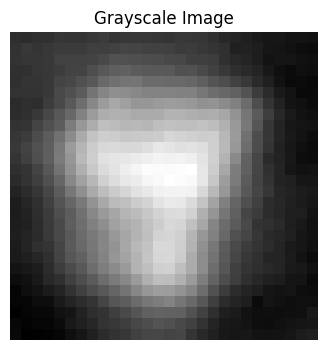

In [35]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Assuming your tensor is named 'image_tensor'
# image_tensor = torch.Size([1, 1, 28, 28])

def plot_grayscale_tensor(image_tensor, threshold=0.0):
    # Remove batch and channel dimensions: [1, 1, 28, 28] -> [28, 28]
    image = image_tensor.squeeze().numpy()
    
    # Apply threshold filtering
    image = np.where(image < threshold, 0, image)
    
    # Create the plot
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap='gray')
    plt.axis('off')  # Turn off axes
    plt.title('Grayscale Image')
    plt.show()

# Example usage:
plot_grayscale_tensor(constructed)

In [36]:
print(constructed)

tensor([[[[-4.6755e-03, -9.4555e-03,  1.1129e-04,  3.3838e-03,  2.0689e-02,
            1.5590e-02,  1.6481e-02,  2.1900e-02,  3.4842e-02,  1.7443e-02,
            2.2937e-02,  2.3496e-02,  2.3245e-02,  1.8615e-02,  1.2664e-02,
            2.7368e-02,  2.3253e-02,  2.0289e-02,  1.4601e-03, -2.2738e-02,
           -3.3707e-02, -4.3838e-02, -6.4602e-02, -7.1573e-02, -7.3147e-02,
           -8.3973e-02, -8.6362e-02, -9.2003e-02],
          [ 9.0835e-03,  2.9593e-02,  1.7823e-02,  2.7388e-02,  3.3759e-02,
            3.5917e-02,  3.5579e-02,  4.7556e-02,  4.6976e-02,  5.6904e-02,
            6.5306e-02,  6.2525e-02,  5.2839e-02,  5.3712e-02,  5.1163e-02,
            3.6364e-02,  3.8787e-02,  2.9581e-02,  1.8268e-02,  6.0144e-03,
           -4.2391e-02, -3.9017e-02, -5.1397e-02, -7.4762e-02, -8.3031e-02,
           -9.1656e-02, -1.0280e-01, -1.0485e-01],
          [ 1.1694e-02,  2.0538e-02,  2.0314e-02,  2.7028e-02,  5.2633e-02,
            5.6857e-02,  5.4624e-02,  5.8325e-02,  7.2657e-02,

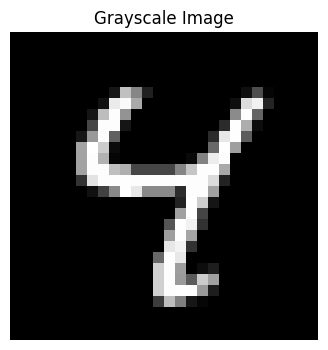

In [37]:
plot_grayscale_tensor(img)

In [38]:
spikes_on,_,images=next(iter(test_loader))
img=images[2]

print(img)


tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [39]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import copy
Epochs = 10
model=best_model
model.to(device)
criterion = torch.nn.MSELoss()
optimizer = Adam(params=model.parameters(), lr=1e-7)
scheduler = CosineAnnealingLR(optimizer, T_max=Epochs, eta_min=1e-6)

best_model = None
best_loss = +torch.inf

for epoch in range(Epochs):
    train_loss = 0.
    val_loss = 0.

    # --- Training ---
    model.train()
    for spikes_on, _, images in tqdm(train_loader, desc=f'Epoch {epoch+1}/{Epochs}'):
        optimizer.zero_grad()
        spikes_on = spikes_on.float().to(device)
        images = images.float().to(device)

        out = model(spikes_on)
        loss = criterion(out, images)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --- Step scheduler after each epoch ---
    scheduler.step()

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        for spikes_on, _, images in tqdm(test_loader, desc='Validation'):
            spikes_on = spikes_on.float().to(device)
            images = images.float().to(device)

            out_val = model(spikes_on)
            loss = criterion(out_val, images)

            val_loss += loss.item()

    # Save best model weights
    if val_loss < best_loss:
        print('New model saved')
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())

    current_lr = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch+1}/{Epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.2e}')

Epoch 1/10:   0%|          | 0/4800 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([10, 1, 1, 28, 28])) that is different to the input size (torch.Size([10, 1, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Validation: 100%|██████████| 1000/1000 [01:00<00:00, 16.57it/s]


New model saved
Epoch 1/10 | Train Loss: 358.0307 | Val Loss: 80.0455 | LR: 1.22e-07


Epoch 2/10:   4%|▍         | 190/4800 [00:12<05:11, 14.80it/s]


KeyboardInterrupt: 

In [ ]:
#from torch.optim import Adam
#from tqdm import tqdm
#criterion=torch.nn.MSELoss()
#optimizer=Adam(params=model.parameters(),lr=1e-3)
#best_model=None
#best_loss=+torch.inf
#Epochs=10
#for epoch in range(Epochs):
#    train_loss=0.
#    val_loss=0.
#    for spikes_on ,_,images in tqdm(train_loader,desc=f'Epoch{epoch+1}/{Epochs}',leave=True):
#        optimizer.zero_grad()
#        spikes_on = spikes_on.float()
#        spikes_on=spikes_on.to(device)
#        images=images.float()
#        images=images.to(device)
#        out=model(spikes_on)
#        loss=criterion(out,images)
#        train_loss+=loss
#        loss.backward()
#        optimizer.step()
#    print('Training Loss :',train_loss.item())
#    for spikes_on ,_,images in tqdm(test_loader,desc=f'Validation',leave=True):
#        spikes_on = spikes_on.float()
#        images = images.float()
#        spikes_on=spikes_on.to(device)
#        images=images.to(device)
#        out_val=model(spikes_on)
#        loss=criterion(out_val,images)
#        val_loss+=loss
#    if val_loss<best_loss:
#        print('New model saved')
#        best_loss=val_loss
#        best_model=model
#    print('Validation Loss :',val_loss.item())